# Install, Import Library

In [1]:
!pip install openai-clip
!pip install torch
!pip install faiss-gpu-cu11==1.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Created wheel for openai-clip: filename=openai_clip-1.0.1-py3-none-any.whl size=1368605 sha256=6c01113cf8ec1991ae4605341abd3bf01f5ee6b0812f8a8957cfeb6f1193755f
  Stored in directory: /root/.cache/pip/wheels/0d/17/90/042948fd2e2a87f1dcf6db6d438cad015c49db0c53d1d9c7dc
Successfully built openai-clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
import clip
import torch
from PIL import Image
from glob import glob
import os
import random
from tqdm import tqdm
import faiss
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import MarianMTModel, MarianTokenizer 
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
import torch.nn.functional as F

2025-11-11 16:38:37.517937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762879117.710518      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762879117.767668      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ROOT_DIR = '/kaggle/input/mushroom/Dataset/Dataset' #đường dẫn tới dataset nấm 

# CLIP model and LoRA config

In [4]:
model, preprocess = clip.load("ViT-B/32", device=device)

#đóng băng tất cả parameter gốc của mô hình 
for param in model.parameters():
  param.requires_grad = False

#xem cấu trúc image, text encoder
for name, module in model.named_modules():
    if 'visual' in name or 'transformer' in name:
        print(name)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 161MiB/s]


visual
visual.conv1
visual.ln_pre
visual.transformer
visual.transformer.resblocks
visual.transformer.resblocks.0
visual.transformer.resblocks.0.attn
visual.transformer.resblocks.0.attn.out_proj
visual.transformer.resblocks.0.ln_1
visual.transformer.resblocks.0.mlp
visual.transformer.resblocks.0.mlp.c_fc
visual.transformer.resblocks.0.mlp.gelu
visual.transformer.resblocks.0.mlp.c_proj
visual.transformer.resblocks.0.ln_2
visual.transformer.resblocks.1
visual.transformer.resblocks.1.attn
visual.transformer.resblocks.1.attn.out_proj
visual.transformer.resblocks.1.ln_1
visual.transformer.resblocks.1.mlp
visual.transformer.resblocks.1.mlp.c_fc
visual.transformer.resblocks.1.mlp.gelu
visual.transformer.resblocks.1.mlp.c_proj
visual.transformer.resblocks.1.ln_2
visual.transformer.resblocks.2
visual.transformer.resblocks.2.attn
visual.transformer.resblocks.2.attn.out_proj
visual.transformer.resblocks.2.ln_1
visual.transformer.resblocks.2.mlp
visual.transformer.resblocks.2.mlp.c_fc
visual.transf

In [5]:
# Cấu hình LoRA

# truy vấn bằng ảnh tốt nên chỉ chèn vào text encoder, chèn vào khối attention và mlp
config = LoraConfig(
    r=16,                                         # rank của ma trận LoRA
    lora_alpha=32,                                # scaling factor
    target_modules = [                             #chèn LoRA vào lớp nào của model
        "transformer.resblocks.0.attn.out_proj",
        "transformer.resblocks.0.mlp.c_fc",
        "transformer.resblocks.0.mlp.c_proj",
        "transformer.resblocks.1.attn.out_proj",
        "transformer.resblocks.1.mlp.c_fc",
        "transformer.resblocks.1.mlp.c_proj",
        "transformer.resblocks.2.attn.out_proj",
        "transformer.resblocks.2.mlp.c_fc",
        "transformer.resblocks.2.mlp.c_proj",
        "transformer.resblocks.3.attn.out_proj",
        "transformer.resblocks.3.mlp.c_fc",
        "transformer.resblocks.3.mlp.c_proj",
        "transformer.resblocks.4.attn.out_proj",
        "transformer.resblocks.4.mlp.c_fc",
        "transformer.resblocks.4.mlp.c_proj",
        "transformer.resblocks.5.attn.out_proj",
        "transformer.resblocks.5.mlp.c_fc",
        "transformer.resblocks.5.mlp.c_proj",
        "transformer.resblocks.6.attn.out_proj",
        "transformer.resblocks.6.mlp.c_fc",
        "transformer.resblocks.6.mlp.c_proj",
        "transformer.resblocks.7.attn.out_proj",
        "transformer.resblocks.7.mlp.c_fc",
        "transformer.resblocks.7.mlp.c_proj",
        "transformer.resblocks.8.attn.out_proj",
        "transformer.resblocks.8.mlp.c_fc",
        "transformer.resblocks.8.mlp.c_proj",
        "transformer.resblocks.9.attn.out_proj",
        "transformer.resblocks.9.mlp.c_fc",
        "transformer.resblocks.9.mlp.c_proj",
        "transformer.resblocks.10.attn.out_proj",
        "transformer.resblocks.10.mlp.c_fc",
        "transformer.resblocks.10.mlp.c_proj",
        "transformer.resblocks.11.attn.out_proj",
        "transformer.resblocks.11.mlp.c_fc",
        "transformer.resblocks.11.mlp.c_proj",
    ],  
    lora_dropout=0.05,
    bias='none',
    task_type='FEATURE_EXTRACTION'             #fine tune để dùng mô hình làm trích chọn đặc trưng
)

model = get_peft_model(model, config)  
model.print_trainable_parameters()

trainable params: 2,949,120 || all params: 154,226,433 || trainable%: 1.9122


# Create Prompt, Text, Image Augmentation

In [6]:
# Tạo prompt (caption/text) từ file JSON chứa các metadata thông tin nấm 

#Tách các thông tin của nấm và tạo thành từng prompt
def create_prompt(data):
  batch_text = []

  # Binomial nomenclature + common name
  text = f"This fungus has the scientific name {data['binomialNomenclature']}. "
  text += f"It's common names in English are: {', '.join(data['commonNames']['en'])} "
  text += f"It's common names in Vietnamese are: {', '.join(data['commonNames']['vi'])}"
  batch_text.append(text)

  if data.get('habitat'):
    batch_text.append(data['habitat'])
  if data.get('shortDescription'):
    batch_text.append(data['shortDescription'])
  if data.get('edibility') and data.get('isPoisonous'):
    text = f"{data['edibility']}. "
    if data['isPoisonous'] == 'True':
      text += 'This fungus is poisonous.'
    else:
      text += 'This fungus is not poisonous.'
    batch_text.append(text)
  if data.get('benefitsOrToxicity'):
    batch_text.append(data['benefitsOrToxicity'])
  if data.get('identification'):
    iden = data['identification']
    text = []
    for part in ['cap', 'gills', 'stem', 'flesh', 'sporePrint', 'taste', 'odor', 'microscopicFeatures']:
      if iden.get(part):
        text.append(f'{part.capitalize()}: {iden[part]}')
    if text:
        batch_text.append('Identification features include: ' + ', '.join(text))
  if data.get('medicinalProperties'):
    batch_text.append(data['medicinalProperties'])
  if data.get('note'):
    batch_text.append(data['note'])
  return batch_text, data['binomialNomenclature']

# Tạo prompt, ghép mỗi đường dẫn ảnh với các text và binomial_name tương ứng 
prompts = []

for json_file in glob(os.path.join(ROOT_DIR, '**/*.json'), recursive=True):
    folder = os.path.dirname(json_file)
    image_dir = os.path.join(folder, 'Images')
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png']:
        image_files.extend(glob(os.path.join(image_dir, f'*{ext}')))
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for img_path in image_files:
            prompt, binomial_name = create_prompt(data)
            for txt in prompt:
                prompts.append({
                    'img_path': img_path,
                    'binomial_name': binomial_name,
                    'text': txt
                })

# Save
with open('/kaggle/working/fungi_prompts.json', 'w', encoding='utf-8') as f:
    json.dump(prompts, f, ensure_ascii=False, indent=4)

print("Completeave prompts in fungi_prompts.json")

Completeave prompts in fungi_prompts.json


In [ ]:
# Text Augmentation: Back Transalation
#Không dùng EDA text để tăng cường text do có thể mất những từ quan trọng và ngữ nghĩa(xóa từ, hoán từ, thay thế...)

#model dịch từ anh -> pháp 
en_to_fr_model_name = 'Helsinki-NLP/opus-mt-en-fr' 
en_to_fr_tkn = MarianTokenizer.from_pretrained(en_to_fr_model_name) 
en_to_fr_model = MarianMTModel.from_pretrained(en_to_fr_model_name).to(device) 
#model dịch từ pháp -> anh 
fr_to_en_model_name = 'Helsinki-NLP/opus-mt-fr-en' 
fr_to_en_tkn = MarianTokenizer.from_pretrained(fr_to_en_model_name) 
fr_to_en_model = MarianMTModel.from_pretrained(fr_to_en_model_name).to(device)

def back_translate_batch(texts, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="back translate"):
        batch = texts[i:i + batch_size]

        # anh -> pháp 
        inputs = en_to_fr_tkn(batch, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            tmp = en_to_fr_model.generate(**inputs, max_length=256)
        fr_texts = [en_to_fr_tkn.decode(t, skip_special_tokens=True) for t in tmp]

        #pháp -> anh
        inputs_fr = fr_to_en_tkn(fr_texts, return_tensors="pt", padding=True, truncation=True)
        inputs_fr = {k: v.to(device) for k, v in inputs_fr.items()}
        with torch.no_grad():
            back = fr_to_en_model.generate(**inputs_fr, max_length=256)
        en_texts = [fr_to_en_tkn.decode(t, skip_special_tokens=True) for t in back]

        results.extend(en_texts)
    return results


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [8]:
#Load prompt từ file đã lưu


with open("/kaggle/working/fungi_prompts.json", "r", encoding='utf-8') as f:
  prompts = json.load(f)

print(f"Loaded {len(prompts)} prompts")

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loaded 26188 prompts


In [9]:
#augment text và thêm vào tập prompt

sample_prompts = random.sample(prompts, k=int(0.3 * len(prompts)))
texts_to_aug = [p["text"] for p in sample_prompts]

aug_texts = back_translate_batch(texts_to_aug, batch_size=32)

expanded_prompts = prompts.copy()
for p, aug_text in zip(sample_prompts, aug_texts):
    if aug_text.strip() != p["text"].strip():  # tránh trùng
        expanded_prompts.append({
            "img_path": p["img_path"],
            "binomial_name": p["binomial_name"],
            "text": aug_text
        })

with open('/kaggle/workingfungi_prompts_expanded.json', 'w', encoding='utf-8') as f: 
    json.dump(expanded_prompts, f, ensure_ascii=False, indent=2)

print("Expanded prompts:", len(expanded_prompts)) 


back translate: 100%|██████████| 246/246 [1:07:45<00:00, 16.52s/it]


Expanded prompts: 33944


In [10]:
# Image Augmentation

train_transform = transforms.Compose([ 
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.75, 1.33)), 
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8), 
    transforms.RandomGrayscale(p=0.1), 
    transforms.RandomRotation(15), 
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)), 
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073], 
        std=[0.26862954, 0.26130258, 0.27577711]), 
])

# Dataset Dataloader

In [11]:
class FungiDataset(Dataset):
  def __init__(self, prompts, preprocess, augment=False):
    self.image_paths = [p['img_path'] for p in prompts]
    self.texts = [p['text'] for p in prompts]
    self.preprocess = preprocess
    self.augment = augment

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    image = Image.open(self.image_paths[idx]).convert("RGB")
    if self.augment: 
        image = train_transform(image) #nếu là tập tập train thì ảnh biến đổi 
    else: 
        image = self.preprocess(image) #nếu là tập valid thì dùng preprocess gốc của clip
    text = clip.tokenize([self.texts[idx]], truncate=True)[0]
    
    return image, text

In [12]:
from sklearn.model_selection import train_test_split

labels = [p['binomial_name'] for p in expanded_prompts]
train_prompts, val_prompts = train_test_split(
    expanded_prompts,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

#tập train thì augment ảnh, valid thì dùng preprocess gốc 
train_dataset = FungiDataset(train_prompts, preprocess, augment=True)     
val_dataset = FungiDataset(val_prompts, preprocess, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Train model

In [13]:
# Loss function

def evaluate(model, loader, device, temperature=0.07):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for images, texts in pbar:
            images = images.to(device)
            texts = texts.to(device)

            img_emb = model.encode_image(images)
            txt_emb = model.encode_text(texts)

            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

            logits_per_img = img_emb @ txt_emb.T
            logits_per_txt = txt_emb @ img_emb.T
            labels = torch.arange(len(images), device=device)

            loss_i = F.cross_entropy(logits_per_img / temperature, labels)
            loss_t = F.cross_entropy(logits_per_txt / temperature, labels)
            loss = (loss_i + loss_t) / 2

            total_loss += loss.item() * len(images)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss

In [14]:
# trainning

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scaler = torch.amp.GradScaler('cuda')
temperature = 0.07
num_epochs = 12
early_stop_patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    pbar = tqdm(train_loader, desc=f'Train Epoch {epoch+1}/{num_epochs}')

    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            img_emb = model.encode_image(images)
            txt_emb = model.encode_text(texts)

            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

            logits_per_img = img_emb @ txt_emb.T
            logits_per_txt = txt_emb @ img_emb.T
            labels = torch.arange(len(images), device=device)

            loss_i = F.cross_entropy(logits_per_img / temperature, labels)
            loss_t = F.cross_entropy(logits_per_txt / temperature, labels)
            loss = (loss_i + loss_t) / 2

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item() * len(images)
        pbar.set_postfix({'train_loss': loss.item()})

    avg_train_loss = total_train_loss / len(train_loader.dataset)

    avg_val_loss = evaluate(model, val_loader, device, temperature)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"Checkpoint saved at epoch {epoch+1}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Train Epoch 1/12: 100%|██████████| 849/849 [11:17<00:00,  1.25it/s, train_loss=1.5]


Epoch 1/12 | Train Loss: 2.5862 | Val Loss: 1.8104
Checkpoint saved at epoch 1


Train Epoch 2/12: 100%|██████████| 849/849 [10:42<00:00,  1.32it/s, train_loss=1.09]


Epoch 2/12 | Train Loss: 1.6468 | Val Loss: 1.3878
Checkpoint saved at epoch 2


Train Epoch 3/12: 100%|██████████| 849/849 [10:26<00:00,  1.36it/s, train_loss=1.19]


...

Epoch 10/12 | Train Loss: 1.0333 | Val Loss: 0.9974
Checkpoint saved at epoch 10


Train Epoch 11/12: 100%|██████████| 849/849 [09:26<00:00,  1.50it/s, train_loss=0.8]


Epoch 11/12 | Train Loss: 1.0070 | Val Loss: 0.9665
Checkpoint saved at epoch 11


Train Epoch 12/12: 100%|██████████| 849/849 [09:50<00:00,  1.44it/s, train_loss=0.82]


Epoch 12/12 | Train Loss: 0.9873 | Val Loss: 0.9566
Checkpoint saved at epoch 12


In [15]:
# lưu adapter lora đã huấn luyện
model.save_pretrained('/kaggle/working/clip_text_lora_adapter')

# Build Faiss index, Retrieve, Visualize

In [16]:
# Tạo embedding cho tất cả ảnh trong dataset

def generate_clip_embeddings(root_dir, model, batch_size=32):
    # lấy đường dẫn toàn bộ ảnh trong dataset 
    image_paths = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_paths.extend(glob(os.path.join(root_dir, '**/*' + ext), recursive=True))
    
    embeddings = []
    model.eval()

    # tạo embedding cho ảnh: lấy ảnh ra theo đường dẫn ảnh, preprocess theo clip rồi .encode_image để lấy embedding ảnh
    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), batch_size), desc="Generating embeddings"):
            batch_paths = image_paths[i:i+batch_size]
            images = []
            
            for img_path in batch_paths:
                try:
                    img = preprocess(Image.open(img_path).convert("RGB"))
                    images.append(img)
                except:
                    print(f"Error loading {img_path}")
                    continue
            
            if images:
                images = torch.stack(images).to(device)
                img_emb = model.encode_image(images)
                img_emb = F.normalize(img_emb, dim=-1)  # Normalize để dùng cosine similarity
                embeddings.append(img_emb.cpu().numpy())
    
    embeddings = np.vstack(embeddings)
    return embeddings, image_paths

In [17]:
    # Tạo faiss để truy vấn nhanh hơn
    
    def create_faiss_index(embeddings, image_paths, output_path):
        dimension = embeddings.shape[1]  #lấy số chiều embeddings
        
        # Dùng IndexFlatIP vì embeddings đã được normalize
        # tích vô hướng của normalize vectors = cosine similarity
        index = faiss.IndexFlatIP(dimension)    #IP: Inner Product: tích vô hướng
        index.add(embeddings.astype('float32'))
        
        faiss.write_index(index, output_path)
        with open(output_path + '.paths', 'w') as f:
            json.dump(image_paths, f)
        
        print(f"lưu faiss index vào {output_path}")
        return index

In [18]:
 # Tìm kiếm ảnh tương tự với query text

def retrieve_similar_images(query_text, model, index, image_paths, top_k=5):
    model.eval()
    
    with torch.no_grad():
        text_tokens = clip.tokenize([query_text], context_length=77, truncate=True).to(device)
        text_emb = model.encode_text(text_tokens)
        text_emb = F.normalize(text_emb, dim=-1)
        text_emb = text_emb.cpu().numpy()   #chuyển từ gpu->cpu vì faiss trên cpu
    
    # Tìm kiếm theo scores là cosine similarity luôn (vì dùng IP với normalized vectors)
    scores, indices = index.search(text_emb.astype('float32'), top_k) #tính cosine giữa query và từng vector trong index
    #score: mảng chứa điểm cosine, indices chứa đường dẫn ảnh
    
    retrieved_images = [image_paths[idx] for idx in indices[0]]
    cosine_scores = scores[0]  #cosine similarity
    
    return query_text, retrieved_images, cosine_scores

In [19]:
# trực quan 

def visualize_results(query, retrieved_images, scores, num_display=5):
    num_display = min(num_display, len(retrieved_images))
    
    fig, axes = plt.subplots(1, num_display, figsize=(4*num_display, 4))
    if num_display == 1:
        axes = [axes]
    
    for idx, (img_path, score) in enumerate(zip(retrieved_images[:num_display], scores[:num_display])):
        img = Image.open(img_path)
        mushroom_name = "_".join(os.path.basename(os.path.dirname(os.path.dirname(img_path))).split("_")[1:])
        axes[idx].imshow(img)
        axes[idx].axis('off')
        # Hiển thị cosine similarity score
        axes[idx].set_title(f'Rank {idx} |{mushroom_name}| Cosine: {score:.4f}', fontsize=10)
    
    plt.suptitle(f'Query: {query}...', fontsize=12)
    plt.tight_layout()
    plt.show()

# Load Trained Model, Faiss index

In [20]:
#Load model sau khi đã lưu

base_model, preprocess = clip.load("ViT-B/32", device=device)
model = PeftModel.from_pretrained(base_model, "/kaggle/working/clip_text_lora_adapter").to(device)
model.eval()

PeftModelForFeatureExtraction(
  (base_model): LoraModel(
    (model): CLIP(
      (visual): VisionTransformer(
        (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (transformer): Transformer(
          (resblocks): Sequential(
            (0): ResidualAttentionBlock(
              (attn): MultiheadAttention(
                (out_proj): lora.Linear(
                  (base_layer): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, out_features=768, bias=False)
                  )
            

In [21]:
# Faiss index 

OUTPUT_INDEX_PATH_FINE = '/kaggle/working/vector_finetuned.index'
embeddings, image_paths_index = generate_clip_embeddings(ROOT_DIR, model, batch_size=32)
index = create_faiss_index(embeddings, image_paths_index, OUTPUT_INDEX_PATH_FINE)

Generating embeddings: 100%|██████████| 108/108 [00:31<00:00,  3.38it/s]

lưu faiss index vào /kaggle/working/vector_finetuned.index


# Retrieve a sample 

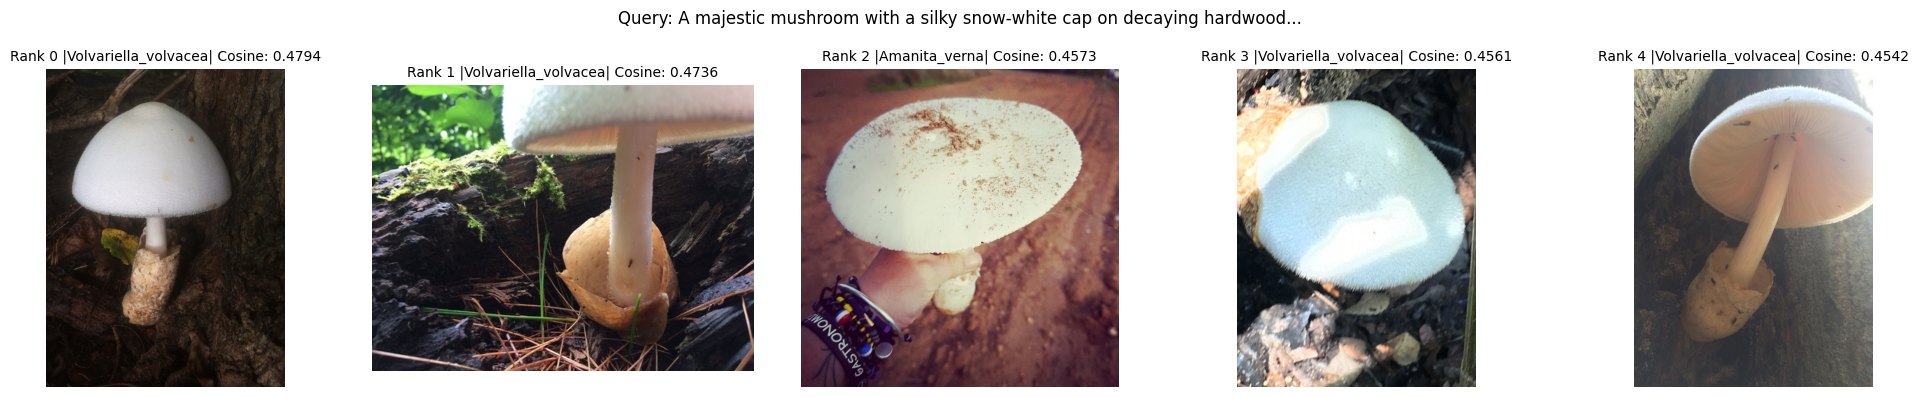

In [22]:
query_text = 'A majestic mushroom with a silky snow-white cap on decaying hardwood'
query, retrieved_images, scores = retrieve_similar_images(query_text, model, index, image_paths_index, top_k=5)
visualize_results(query, retrieved_images, scores, num_display=10)

# Evaluate: Precision@k, Recall@k, mAP, mRR

## Đánh giá theo P

In [23]:
import pandas as pd
import re

def evalute_metrics(df, model, index, image_paths_index, prompts, top_k=5, device='cuda'):
    queries = df["query"].tolist()
    labels = df["label"].tolist()

    img_label_map = {}
    for p in prompts:
        img_path = p["img_path"]
        lbl = re.sub("_", " ", p["binomial_name"].strip().lower())
        img_label_map[img_path] = lbl 

    labels = [re.sub("_", " ", lbl.strip().lower()) for lbl in labels]

    label_counts = {}
    for lbl in img_label_map.values():
        label_counts[lbl] = label_counts.get(lbl, 0) + 1

    precisions, recalls, aps, rrs = [], [], [], []

    model.eval()

    for query, label in tqdm(zip(queries, labels), total=len(queries), desc="Evaluating"):
        with torch.no_grad():
            text_token = clip.tokenize([query], truncate=True).to(device)
            text_emb = model.encode_text(text_token)
            text_emb = F.normalize(text_emb, dim=-1)
            text_emb = text_emb.cpu().numpy()

        scores, indices = index.search(text_emb.astype("float32"), top_k)
        retrieved_imgs = [image_paths_index[i] for i in indices[0]]

        retrieved_labels = []
        for img_path in retrieved_imgs:
            lbl = img_label_map.get(img_path, "")
            retrieved_labels.append(lbl)

        relevant = [1 if lbl == label else 0 for lbl in retrieved_labels]

        total_hits = sum(relevant)
        total_relevant = label_counts.get(label, 0)

        precision = total_hits / top_k
        recall = total_hits / total_relevant if total_relevant > 0 else 0

        cum_hits = np.cumsum(relevant)
        precisions_at_k = cum_hits / (np.arange(len(relevant)) + 1)
        ap = (precisions_at_k * relevant).sum() / total_relevant if total_relevant > 0 else 0

        rr = 1 / (np.where(np.array(relevant) == 1)[0][0] + 1) if 1 in relevant else 0

        precisions.append(precision)
        recalls.append(recall)
        aps.append(ap)
        rrs.append(rr)

    results = {
        f"Precision@{top_k}": np.mean(precisions),
        f"Recall@{top_k}": np.mean(recalls),
        "mAP": np.mean(aps),
        "mRR": np.mean(rrs)
    }

    return results

In [24]:
benchmark_path = "/kaggle/input/mushroom/test_query_fixed.csv"
df = pd.read_csv(benchmark_path)
print(f"Loaded {len(df)} queries")

k = [1, 5, 10, 100, 1000]
for idx in k: 
    metrics = evalute_metrics(df, model=model, index=index,image_paths_index=image_paths_index, prompts=prompts, top_k=idx, device=device)
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}", end ="||")
    print("")

Loaded 491 queries


Evaluating: 100%|██████████| 491/491 [00:07<00:00, 68.27it/s]


Precision@1: 0.2872||Recall@1: 0.0029||mAP: 0.0029||mRR: 0.2872||


Evaluating: 100%|██████████| 491/491 [00:07<00:00, 68.01it/s]


Precision@5: 0.2978||Recall@5: 0.0154||mAP: 0.0137||mRR: 0.3397||


...

Precision@10: 0.2941||Recall@10: 0.0304||mAP: 0.0261||mRR: 0.3459||


Evaluating: 100%|██████████| 491/491 [00:07<00:00, 68.05it/s]


Precision@100: 0.2462||Recall@100: 0.2516||mAP: 0.1818||mRR: 0.3540||


Evaluating: 100%|██████████| 491/491 [00:07<00:00, 64.25it/s]

Precision@1000: 0.0704||Recall@1000: 0.6822||mAP: 0.2692||mRR: 0.3550||


# Đánh giá theo T

In [25]:
import json

def normalize_label(label):
    label = re.sub(r'^\d+_', '', label)  # bỏ tiền tố số
    label = label.replace('_', ' ').strip().lower()
    return label

def convert_json_multi_label(json_path, output_csv_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    rows = []
    for item in data:
        query = item["query_text"].strip()
        labels = [normalize_label(lbl) for lbl in item["ground_truth_species"]]
        rows.append({"query": query, "labels": labels})

    df = pd.DataFrame(rows)
    df.to_csv(output_csv_path, index=False)
    print(f"Saved multi-label test CSV to: {output_csv_path}")

json_path = "/kaggle/input/mushroom/queries.json"
output_csv_path = "/kaggle/working/test_query_multi.csv"
convert_json_multi_label(json_path, output_csv_path)


Saved multi-label test CSV to: /kaggle/working/test_query_multi.csv


In [26]:

def evalute_metrics(csv_path, model, index, image_paths_index, prompts, top_k=5, device='cuda'):
    df = pd.read_csv(csv_path, converters={"labels": eval})

    queries = df["query"].tolist()
    multi_labels = df["labels"].tolist()  # list[list]

    img_label_map = {
        p["img_path"]: re.sub("_", " ", p["binomial_name"].strip().lower())
        for p in prompts
    }

    label_counts = {}
    for lbl in img_label_map.values():
        label_counts[lbl] = label_counts.get(lbl, 0) + 1

    precisions, recalls, aps, rrs = [], [], [], []

    model.eval()

    for query, true_labels in tqdm(zip(queries, multi_labels), total=len(queries), desc="Evaluating"):
        true_labels = [lbl.strip().lower() for lbl in true_labels]

        with torch.no_grad():
            text_token = clip.tokenize([query], truncate=True).to(device)
            text_emb = model.encode_text(text_token)
            text_emb = F.normalize(text_emb, dim=-1)
            text_emb = text_emb.cpu().numpy()

        scores, indices = index.search(text_emb.astype("float32"), top_k)
        retrieved_imgs = [image_paths_index[i] for i in indices[0]]

        retrieved_labels = [img_label_map.get(img_path, "") for img_path in retrieved_imgs]

        relevant = [1 if lbl in true_labels else 0 for lbl in retrieved_labels]
        total_hits = sum(relevant)

 
        total_relevant = sum(label_counts.get(lbl, 0) for lbl in true_labels)

        precision = total_hits / top_k
        recall = total_hits / total_relevant if total_relevant > 0 else 0

        # Average Precision (AP)
        cum_hits = np.cumsum(relevant)
        precisions_at_k = cum_hits / (np.arange(len(relevant)) + 1)
        ap = (precisions_at_k * relevant).sum() / total_relevant if total_relevant > 0 else 0

        # Reciprocal Rank
        rr = 1 / (np.where(np.array(relevant) == 1)[0][0] + 1) if 1 in relevant else 0

        precisions.append(precision)
        recalls.append(recall)
        aps.append(ap)
        rrs.append(rr)

    results = {
        f"Precision@{top_k}": np.mean(precisions),
        f"Recall@{top_k}": np.mean(recalls),
        "mAP": np.mean(aps),
        "mRR": np.mean(rrs)
    }

    return results


In [27]:
import pandas as pd

benchmark_path = "/kaggle/working/test_query_multi.csv"
k_values = [1, 5, 10, 50, 100, 1000]

for k in k_values:
    metrics = evalute_metrics(csv_path=benchmark_path, model=model, index=index, image_paths_index=image_paths_index, prompts=prompts, top_k=k, device=device)
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}", end ="||")
    print("")

Evaluating: 100%|██████████| 100/100 [00:01<00:00, 67.00it/s]


Precision@1: 0.5500||Recall@1: 0.0035||mAP: 0.0035||mRR: 0.5500||


Evaluating: 100%|██████████| 100/100 [00:01<00:00, 69.83it/s]


Precision@5: 0.5300||Recall@5: 0.0167||mAP: 0.0159||mRR: 0.6070||


Evaluating: 100%|██████████| 100/100 [00:01<00:00, 69.21it/s]


...

Precision@50: 0.4912||Recall@50: 0.1503||mAP: 0.1294||mRR: 0.6195||


Evaluating: 100%|██████████| 100/100 [00:01<00:00, 67.10it/s]


Precision@100: 0.4506||Recall@100: 0.2624||mAP: 0.2126||mRR: 0.6201||


Evaluating: 100%|██████████| 100/100 [00:01<00:00, 63.04it/s]

Precision@1000: 0.1939||Recall@1000: 0.6670||mAP: 0.3599||mRR: 0.6204||
